## TP4.1 a) États stationnaires

On part de l’équation :

$$
\frac{di}{d\tau} = (R_0 - 1)i - R_0 i^2
$$

On cherche les états stationnaires en posant :

$$
\frac{di}{d\tau} = 0
$$

Donc :

$$
(R_0 - 1)i - R_0 i^2 = 0
$$

En factorisant :

$$
i \left[(R_0 - 1) - R_0 i \right] = 0
$$

On obtient deux solutions :

- Premier état stationnaire :
$$
i_1^* = 0
$$

- Deuxième état stationnaire :
$$
(R_0 - 1) - R_0 i = 0
$$

$$
R_0 i = R_0 - 1
$$

$$
i_2^* = \frac{R_0 - 1}{R_0} = 1 - \frac{1}{R_0}
$$


Les états stationnaires sont les valeurs de $i$ pour lesquelles l’évolution s’arrête ($di/d\tau = 0$).  
L’état $i=0$ correspond à une population sans infection.  
L’état endémique ($i = 1 - \frac{1}{R_0}$) correspond à une situation où l’infection persiste de façon stable dans la population (elle ne disparaît pas).

## TP4.1 b) Solution analytique

On considère l’équation :

$$
\frac{di}{d\tau} = (R_0 - 1)i - R_0 i^2
$$

Cette équation est de type logistique (ou Bernoulli). On peut la résoudre par séparation des variables :

$$
\frac{di}{i[(R_0 - 1) - R_0 i]} = d\tau
$$


$$
\ln\left|\frac{i}{(R_0 - 1) - R_0 i}\right| = (R_0 - 1)\tau + C
$$


$$
\frac{i}{(R_0 - 1) - R_0 i}
= \frac{i_0}{(R_0 - 1) - R_0 i_0} \, e^{(R_0 - 1)\tau}
$$


$$
i(\tau) = \frac{(R_0 - 1)\, i_0 \, e^{(R_0 - 1)\tau}}
{(R_0 - 1) + R_0 i_0 \left(e^{(R_0 - 1)\tau} - 1\right)}
$$

  
La solution décrit une croissance logistique. Si $R_0 > 1$, l’infection augmente puis se stabilise vers l’état endémique. Si $R_0 \le 1$, l’infection diminue progressivement et disparaît. Cette solution servira de référence pour évaluer l’erreur des méthodes numériques.

## TP4.1 c) Implémentation des intégrateurs numériques

On implémente les méthodes d’Euler, de Runge-Kutta d’ordre 2 et d’ordre 4 pour résoudre numériquement l’équation et obtenir les trajectoires $i(\tau)$ et $\tau$.

Le code est le suivant :

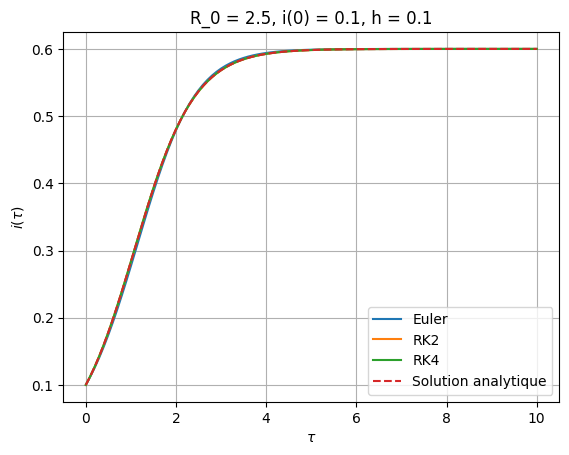

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f_sis(i, tau, R0):
    return (R0 - 1) * i - R0 * i**2

def sol_analytique(tau, i0, R0):
    k = R0 - 1
    numerator = k * i0 * np.exp(k * tau)
    denominator = k + R0 * i0 * (np.exp(k * tau) - 1)
    return numerator / denominator

def solve_euler(i0, tau_max, h, R0):
    tpoints = np.arange(0, tau_max + h, h)
    ipoints = []
    i = i0
    for tau in tpoints:
        ipoints.append(i)
        i += h * f_sis(i, tau, R0)
    return tpoints, np.array(ipoints)

def solve_rk2(i0, tau_max, h, R0):
    tpoints = np.arange(0, tau_max + h, h)
    ipoints = []
    i = i0
    for tau in tpoints:
        ipoints.append(i)
        k1 = h * f_sis(i, tau, R0)
        k2 = h * f_sis(i + 0.5 * k1, tau + 0.5 * h, R0)
        i += k2
    return tpoints, np.array(ipoints)

def solve_rk4(i0, tau_max, h, R0):
    tpoints = np.arange(0, tau_max + h, h)
    ipoints = []
    i = i0
    for tau in tpoints:
        ipoints.append(i)
        k1 = h * f_sis(i, tau, R0)
        k2 = h * f_sis(i + 0.5 * k1, tau + 0.5 * h, R0)
        k3 = h * f_sis(i + 0.5 * k2, tau + 0.5 * h, R0)
        k4 = h * f_sis(i + k3, tau + h, R0)
        i += (k1 + 2*k2 + 2*k3 + k4) / 6
    return tpoints, np.array(ipoints)


i0 = 0.10
R0 = 2.5
tau_max = 10
h = 0.1

t_euler, i_euler = solve_euler(i0, tau_max, h, R0)
t_rk2, i_rk2 = solve_rk2(i0, tau_max, h, R0)
t_rk4, i_rk4 = solve_rk4(i0, tau_max, h, R0)

t_exact = np.linspace(0, tau_max, 1000)
i_exact = sol_analytique(t_exact, i0, R0)

plt.figure()
plt.plot(t_euler, i_euler, label="Euler")
plt.plot(t_rk2, i_rk2, label="RK2")
plt.plot(t_rk4, i_rk4, label="RK4")
plt.plot(t_exact, i_exact, linestyle='--', label="Solution analytique")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$i(\tau)$")
plt.title(f"R_0 = {R0}, i(0) = {i0}, h = {h}")
plt.legend()
plt.grid()

plt.show()

Pour simuler la dynamique SIS, on a utilisé trois méthodes numériques, soit Euler, Runge-Kutta d’ordre 2 (RK2) et Runge-Kutta d’ordre 4 (RK4). Euler est simple mais moins précis, car il avance la solution en utilisant seulement la pente actuelle. RK2 améliore la précision en calculant une pente intermédiaire, tandis que RK4 est encore plus précis grâce à la moyenne pondérée de quatre pentes à chaque pas. En comparant ces méthodes à la solution analytique, on voit qu’Euler s’écarte le plus, RK2 suit mieux, et RK4 reproduit quasiment exactement la trajectoire de la fraction infectée `i(τ)` sur tout l’intervalle de temps. Cependant, si le pas de temps est assez petit, toutes les courbes collent très bien à la solution analytique. On peut visualiser ces différences dans les graphiques suivants pour `h = 0.1 , 0.5 et 1`. 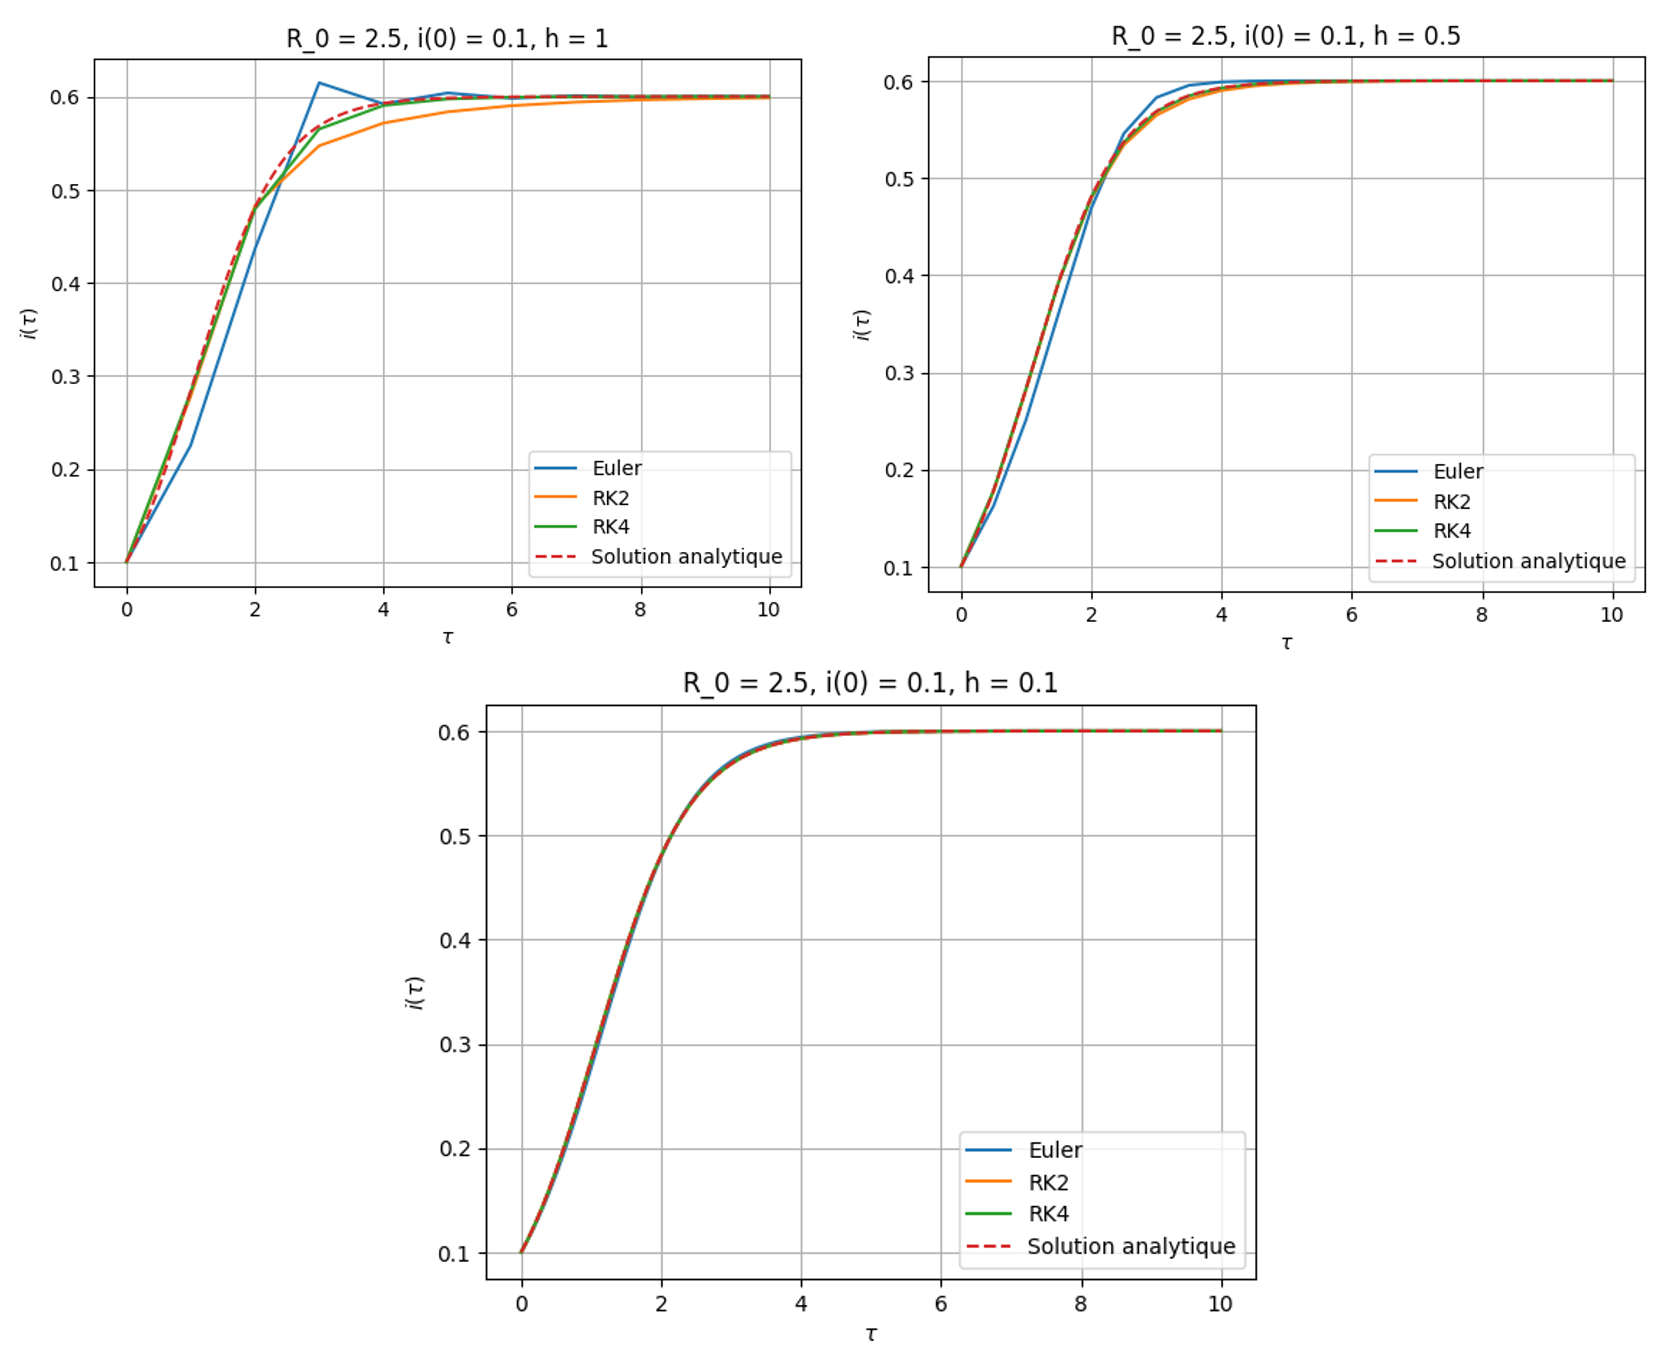

## TP4.1 d) Choix du pas d'intégration

On cherche à déterminer un pas de temps $h$ pour chaque intégrateur afin que l'erreur entre la trajectoire numérique et la solution analytique reste dans l'intervalle souhaité. La méthode du ratio doré est utilisée pour optimiser ce pas et contrôler la précision des simulations. Le code est le suivant : 

In [2]:
import numpy as np

def erreur_rms(i_num, tau, i0, R0): 
    i_exact = sol_analytique(tau, i0, R0)
    return np.sqrt(np.mean((i_num - i_exact)**2))

# ratio doré
def compute_error(integrateur, i0, tau_max, R0, h):
    t, i_num = integrateur(i0, tau_max, h, R0)
    return erreur_rms(i_num, t, i0, R0)


def trouver_h_ratio_doree(integrateur, i0, tau_max, R0, delta,
                         h_min=1e-14, h_max=1.0, tol=0.01, max_iter=20):

    phi = (1 + np.sqrt(5)) / 2
    inv_phi = 1 / phi

    a, b = h_min, h_max
    c = b - inv_phi * (b - a)
    d = a + inv_phi * (b - a)

    eps_c = compute_error(integrateur, i0, tau_max, R0, c)
    eps_d = compute_error(integrateur, i0, tau_max, R0, d)

    for _ in range(max_iter):

        if abs(eps_c - delta)/delta < tol:
            return c
        if abs(eps_d - delta)/delta < tol:
            return d

        if eps_c < delta:
            a = c
            c = d
            eps_c = eps_d

            d = a + inv_phi * (b - a)
            eps_d = compute_error(integrateur, i0, tau_max, R0, d)

        else:
            b = d
            d = c
            eps_d = eps_c

            c = b - inv_phi * (b - a)
            eps_c = compute_error(integrateur, i0, tau_max, R0, c)

        if abs(b - a) < 1e-12:
            break

    return (a + b) / 2

deltas = [1e-9, 1e-8, 1e-7, 1e-6]
i0_values = [0.1, 0.2] 
R0_values = [2.5, 1.5]  
tau_max = 10

resultats = {}

for i0 in i0_values:
    for R0 in R0_values:
        resultats[(i0, R0)] = {}
        for delta in deltas:
            h_euler = trouver_h_ratio_doree(solve_euler, i0, tau_max, R0, delta)
            h_rk2   = trouver_h_ratio_doree(solve_rk2, i0, tau_max, R0, delta)
            h_rk4   = trouver_h_ratio_doree(solve_rk4, i0, tau_max, R0, delta)
            resultats[(i0, R0)][delta] = (h_euler, h_rk2, h_rk4)

for (i0, R0), data in resultats.items():
    print(f"\ni0 = {i0}, R0 = {R0}  |  h pour chaque δ")
    print(f"{'δ':<10} {'Euler':<10} {'RK2':<10} {'RK4':<10}")
    for delta, hs in data.items():
        print(f"{delta:<10.1e} {hs[0]:<10.3e} {hs[1]:<10.3e} {hs[2]:<10.3e}")


i0 = 0.1, R0 = 2.5  |  h pour chaque δ
δ          Euler      RK2        RK4       
1.0e-09    3.305e-05  4.609e-04  3.106e-02 
1.0e-08    3.305e-05  1.433e-03  5.527e-02 
1.0e-07    3.305e-05  4.465e-03  9.830e-02 
1.0e-06    7.391e-05  1.406e-02  1.753e-01 

i0 = 0.1, R0 = 1.5  |  h pour chaque δ
δ          Euler      RK2        RK4       
1.0e-09    3.305e-05  1.639e-03  1.069e-01 
1.0e-08    3.305e-05  5.198e-03  1.897e-01 
1.0e-07    3.305e-05  1.643e-02  3.344e-01 
1.0e-06    2.470e-04  5.189e-02  5.886e-01 

i0 = 0.2, R0 = 2.5  |  h pour chaque δ
δ          Euler      RK2        RK4       
1.0e-09    3.305e-05  5.270e-04  3.517e-02 
1.0e-08    3.305e-05  1.647e-03  6.239e-02 
1.0e-07    3.305e-05  5.132e-03  1.103e-01 
1.0e-06    9.916e-05  1.609e-02  1.935e-01 

i0 = 0.2, R0 = 1.5  |  h pour chaque δ
δ          Euler      RK2        RK4       
1.0e-09    3.305e-05  1.532e-03  1.115e-01 
1.0e-08    3.305e-05  4.852e-03  1.978e-01 
1.0e-07    3.305e-05  1.536e-02  3.475e-01 
1.0e

## TP4.1 e) Ordre de l’erreur

Le code pour trouver l'ordre de l'erreur pour chaque méthode est le suivant :

In [3]:
import numpy as np
import matplotlib.pyplot as plt

deltas_euler = [1e-5,1e-6, 1e-7,] 
deltas_rk = [1e-6, 1e-7, 1e-8, 1e-9]

def calculer_ordre(nom_methode, solveur, d_list):
    hs = []
    epsilons = []
    for d in d_list:
        h = trouver_h_ratio_doree(solveur, i0=0.1, tau_max=10, R0=2.5, delta=d, max_iter=50)
        hs.append(h)
        epsilons.append(compute_error(solveur, 0.1, 10, 2.5, h))
    
    d_ordre, _ = np.polyfit(np.log(hs), np.log(epsilons), 1)
    return d_ordre

ordre_euler = calculer_ordre("Euler", solve_euler, deltas_euler)
ordre_rk2 = calculer_ordre("RK2", solve_rk2, deltas_rk)
ordre_rk4 = calculer_ordre("RK4", solve_rk4, deltas_rk)

print(f"Ordre d (Euler) : {ordre_euler:.3f}")
print(f"Ordre d (RK2)   : {ordre_rk2:.3f}")
print(f"Ordre d (RK4)   : {ordre_rk4:.3f}")

Ordre d (Euler) : 1.000
Ordre d (RK2)   : 2.001
Ordre d (RK4)   : 3.999


Les résultats obtenus correspondent très bien à la théorie attendue pour les intégrateurs numériques. Par contre, on utilise pour la méthode d'Euler des valeurs de $\delta$ plus élevées (moins restrictives) que pour les méthodes de Runge-Kutta afin de respecter les limites pratiques de calcul et de mémoire de l'ordinateur. On utilise des valeurs de $\delta$ plus grandes pour Euler car cette méthode est inutilement lente pour des précisions élevées. En utilisant une plage d'erreurs plus accessibles (ex: $10^{-3}$ à $10^{-6}$), on peut confirmer numériquement que sa pente $d$ est bien de 1.

### 2. Un condensateur électronique

#### 2.a) méthode de Gauss-Seidel avec relaxation

omega = 0.92, temps = 2.4297809000127017


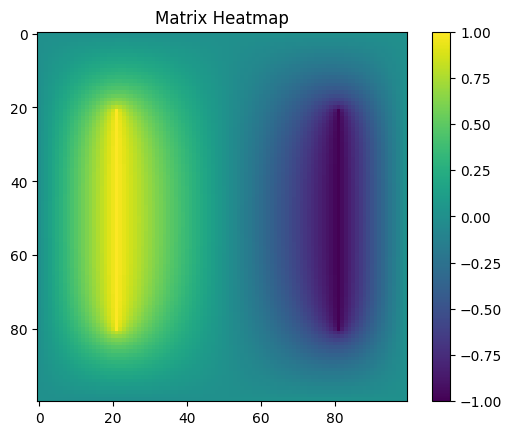

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

start = time.perf_counter()
condo = np.zeros((100, 100), float)
dcondo = np.zeros((100, 100), float)
condo[21:81, 21] = 1
condo[21:81, 81] = -1
omega = 0.92

delta = 1
target = 10e-6
while delta > target:
    for i in range(100):
        for j in range (100):
            if i == 0 or i == 99 or j == 0 or j == 99:
                pass
            elif (j == 21 or j == 81) and (i >= 21 and i <= 80):
                pass
            else:
                dcondo[i,j] = (1+omega)*((condo[i,j+1] + condo[i,j-1] + condo[i+1,j] + condo[i-1,j])/4 - condo[i,j])
                condo[i,j] += dcondo[i,j]

    delta = np.max(np.abs(dcondo))

print(f"omega = {omega}, temps = {time.perf_counter()-start}")
temps.append(time.perf_counter()-start)
omeg.append(omega)


plt.imshow(condo)
plt.colorbar()
plt.title("Matrix Heatmap")
plt.show()

#### 2.b) Effet du paramètre omega sur le temps de traitement de la méthode de Gauss-Seidel

On remarque qu'en utilisant une valeur d'omega trop faible la méthode de Gauss-Seidel prend beaucoup de temps pour converger vers une réponse. En utilisant une valeur trop grande la résolution devient instable et aucune solution n'est trouvé. Dans notre cas, un omega de 0.92 permet de résouder le problème le plus rapidement avec un temps de calcul d'environ 4.6 secondes.

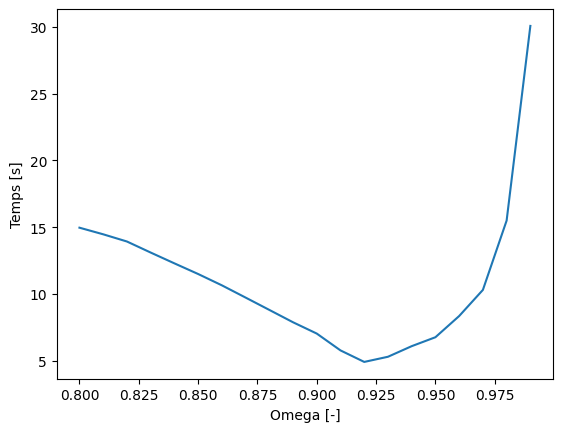

In [ ]:
omeg = [0.8, 0.81, 0.8200000000000001, 0.8300000000000001, 0.8400000000000001, 0.8500000000000001, 0.8600000000000001, 0.8700000000000001, 0.8800000000000001, 0.8900000000000001, 0.9000000000000001, 0.9100000000000001, 0.9200000000000002, 0.9300000000000002, 0.9400000000000002, 0.9500000000000002, 0.9600000000000002, 0.9700000000000002, 0.9800000000000002, 0.9900000000000002]
temps = [14.961928300006548, 14.46697330000461, 13.927888399979565, 13.101793799985899, 12.292735800001537, 11.49598700000206, 10.648866300005466, 9.731841300002998, 8.808545300009428, 7.8830707000161055, 7.037128700001631, 5.776960699993651, 4.915481299976818, 5.3019012000004295, 6.0947386999905575, 6.763952499983134, 8.350215299986303, 10.30569489998743, 15.494322400016245, 30.06184249999933]
plt.plot(omeg, temps)
plt.xlabel("Omega [-]")
plt.ylabel("Temps [s]")
plt.show()

#### 2.c) Méthode de Jacobi 

temps = 12.939523199980613


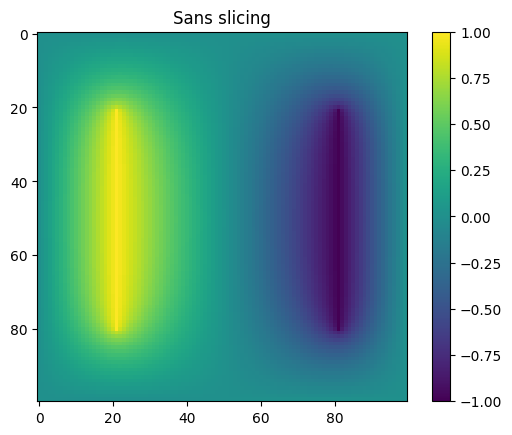

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

start = time.perf_counter()

condo = np.zeros((100, 100), float)
condo_prime = np.empty((100, 100), float)
condo[21:81, 21] = 1
condo[21:81, 81] = -1



delta = 1
target = 10e-6

while delta > target:
    for i in range(100):
        for j in range (100):
            if i == 0 or i == 99 or j == 0 or j == 99:
                condo_prime[i,j] = condo[i,j]
            elif (j == 21 or j == 81) and (i >= 21 and i <= 80):
                condo_prime[i,j] = condo[i,j]
            else:
                condo_prime[i,j] = (condo[i,j+1] + condo[i,j-1] + condo[i+1,j] + condo[i-1,j])/4

    delta = np.max(np.abs(condo - condo_prime))
    condo_prime, condo = condo, condo_prime

print(f"temps = {time.perf_counter()-start}")

plt.imshow(condo)
plt.colorbar()
plt.title("Sans slicing")
plt.show()


temps = 0.07320230000186712


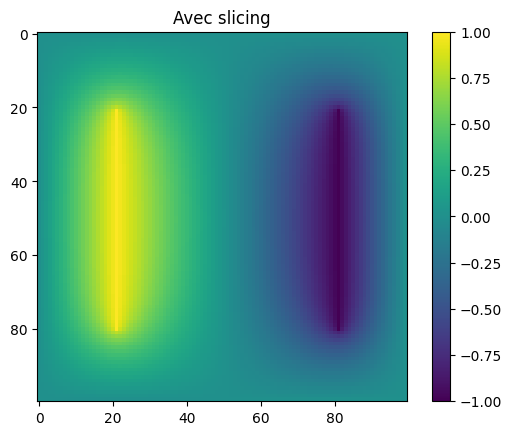

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

start = time.perf_counter()

condo = np.zeros((100, 100), float)
condo_prime = np.empty((100, 100), float)
condo[21:81, 21] = 1
condo[21:81, 81] = -1



delta = 1
target = 10e-6

while delta > target:


    condo_prime[1:-1, 1:-1] = 0.25 * (
        condo[1:-1, 2:] +    
        condo[1:-1, :-2] +   
        condo[2:, 1:-1] +    
        condo[:-2, 1:-1])    

    condo_prime[0, :]  = condo[0, :]
    condo_prime[-1, :] = condo[-1, :]
    condo_prime[:, 0]  = condo[:, 0]
    condo_prime[:, -1] = condo[:, -1]

    condo_prime[21:81, 21] = condo[21:81, 21]
    condo_prime[21:81, 81] = condo[21:81, 81]

    delta = np.max(np.abs(condo - condo_prime))

    condo, condo_prime = condo_prime, condo

print(f"temps = {time.perf_counter()-start}")

plt.imshow(condo)
plt.colorbar()
plt.title("Avec slicing")
plt.show()

En comparant les trois méthodes, on remarques que la méthode la plus rapide pour une grille de 100x100 est celle de Jacobi avec slicing avec un temps de 0.073 secondes. La seconde plus rapide est celle de Gauss-Seidel avec un temps de 4.6 secondes. Finalement, la moins rapide des méthodes est celle de Jacobi sans slicing avec un temps de 12.9 secondes. On peut aussi conclure que la méthode qui serait la plus efficace pour effectuer cette tâche serait celle de Gauss-Seidel avec slicing.